In [1]:
import os

print(f"1. Diretório de Trabalho Atual (CWD): {os.getcwd()}")

# Recria o caminho que seu código está tentando acessar
base_path = '..\\..\\data'
model_base_path = os.path.join(base_path, 'preprocessors-pipeline')
abs_model_path = os.path.abspath(model_base_path)

print(f"2. Caminho Relativo definido: {model_base_path}")
print(f"3. Caminho Absoluto resolvido: {abs_model_path}")

print(f"4. O diretório existe? {'SIM' if os.path.exists(abs_model_path) else 'NÃO'}")

if os.path.exists(abs_model_path):
    print(f"5. Conteúdo da pasta (primeiros 10 itens):")
    try:
        conteudo = os.listdir(abs_model_path)
        print(conteudo[:10])
    except Exception as e:
        print(f"Erro ao listar diretório: {e}")
else:
    print("CRÍTICO: O Python não está encontrando a pasta 'preprocessors-pipeline' neste caminho.")

1. Diretório de Trabalho Atual (CWD): C:\Users\GabrielMoreira\log-anomaly-detection-ml\notebooks\Ubuntu-Server-Logs
2. Caminho Relativo definido: ..\..\data\preprocessors-pipeline
3. Caminho Absoluto resolvido: C:\Users\GabrielMoreira\log-anomaly-detection-ml\data\preprocessors-pipeline
4. O diretório existe? SIM
5. Conteúdo da pasta (primeiros 10 itens):
['DBSCAN', 'Encoder', 'HDBSCAN', 'IF', 'IF-Subsampled', 'KMeans', 'MBKMeans', 'RF', 'SelfTraining-RF', 'SelfTraining-XGB']


In [2]:
# ### 01. Validação dos Modelos: Binária (Global) e Multiclasse (Supervisionada)
# 
# **Objetivo:** # 1. Avaliar TODOS os modelos na capacidade de detectar intrusão (Binário: Normal vs Attack).
# 2. Avaliar APENAS modelos supervisionados/semi na capacidade de classificar o tipo de ataque (Multiclasse).

import pandas as pd
import numpy as np
import joblib
import json
import warnings
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, balanced_accuracy_score, classification_report
)
import plotly.figure_factory as ff
import plotly.io as pio
from IPython.display import display

# Configurações
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
pio.templates.default = "plotly_dark"

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [3]:
# --- 1. Definição de Caminhos e Grupos ---

base_path = '..\\..\\data' # Ajuste conforme sua estrutura
model_base_path = os.path.join(base_path, 'preprocessors-pipeline') 
validation_dataset_path = os.path.join(base_path, 'processed', 'ubuntu_server_dataset_final_argus.csv')

# Grupo 1: Modelos Supervisionados/Semi (Podem fazer Multiclasse)
MODELS_SUPERVISED = [
    'RandomForest', 'XGBoost', 'SVM', 
    'SelfTraining-RF', 'SelfTraining-XGB'
]

# Grupo 2: Modelos Não Supervisionados (Apenas Binário)
MODELS_UNSUPERVISED = [
    'IsolationForest', 'IsolationForestSubsampled', 
    'KMeans', 'MBKMeans', 'HDBSCAN', 'DBSCAN'
]

# Mapeamento de pastas
model_directories = {
    'RandomForest': 'RF',
    'XGBoost': 'XGB',
    'SVM': 'SVM',
    'SelfTraining-RF': 'SelfTraining-RF',
    'SelfTraining-XGB': 'SelfTraining-XGB',
    'IsolationForest': 'IF',
    'IsolationForestSubsampled': 'IF-Subsampled',
    'KMeans': 'KMeans',
    'MBKMeans': 'MBKMeans',
    'HDBSCAN': 'HDBSCAN',
    'DBSCAN': 'DBSCAN'
}

In [4]:
# --- 2. Carregamento e Preparação dos Dados ---

print(f"Carregando dataset de validação: {validation_dataset_path}...")
df_validation = pd.read_csv(validation_dataset_path, low_memory=False)

# --- LIMPEZA DE SEGURANÇA (Pós-Leitura) ---
coluna_problema = 'response_body_len'
if coluna_problema in df_validation.columns:
    df_validation[coluna_problema] = df_validation[coluna_problema].fillna(0).replace([np.inf, -np.inf], 0)

# Separar X (Features) e y (Labels)
label_cols = ['attack_cat', 'Label']
X_val = df_validation.drop(columns=label_cols, errors='ignore')

# GABARITOS (Ground Truth)
# 1. Gabarito Multiclasse (Texto: 'Normal', 'DoS', etc)
y_val_text = df_validation['attack_cat']

# 2. Gabarito Binário (Numérico: 0=Normal, 1=Ataque)
# Mapeia 'Normal' -> 0 e qualquer outra coisa -> 1
y_val_binary = y_val_text.apply(lambda x: 0 if x == 'Normal' else 1).values

print(f"Dados prontos. Total de amostras: {len(df_validation)}")

Carregando dataset de validação: ..\..\data\processed\ubuntu_server_dataset_final_argus.csv...
Dados prontos. Total de amostras: 340419


In [5]:
# --- 3. Função Auxiliar de Carregamento ---

def load_artifact(file_path):
    if not os.path.exists(file_path):
        return None
    try:
        if file_path.endswith('.joblib'):
            return joblib.load(file_path)
        elif file_path.endswith('.json'):
            with open(file_path, 'r') as f:
                return json.load(f)
    except Exception as e:
        print(f"  Erro ao carregar {file_path}: {e}")
        return None

In [6]:
# --- 4. ETAPA 1: VALIDAÇÃO BINÁRIA (TODOS OS MODELOS) ---
# Aqui normalizamos tudo para 0 (Normal) e 1 (Ataque) para comparação justa.

print("\n=== INICIANDO VALIDAÇÃO BINÁRIA (Detecção de Intrusão) ===")
results_binary = {}
cm_binary = {}

for model_name, model_dir in model_directories.items():
    print(f"\nValidando (Binário): {model_name}...")
    
    # 1. Carregar Artefatos
    path = os.path.join(model_base_path, model_dir)
    print(path)
    pipeline = load_artifact(os.path.join(path, f'pipeline_{model_dir}.joblib'))
    
    model = load_artifact(os.path.join(path, f'model_{model_dir}.joblib'))
    
    preprocessor = load_artifact(os.path.join(path, f'preprocessor_{model_dir}.joblib'))
    threshold_data = load_artifact(os.path.join(path, f'threshold_{model_dir}.json'))
    
    y_pred_bin = None
    
    try:
        # 2. Gerar Predições Brutas e Converter para Binário (0/1)
        
        # CASO A: Modelos Supervisionados (Pipeline ou Modelo+Encoder)
        if model_name in MODELS_SUPERVISED:
            
            # 1. Tenta carregar encoder externo (se existir)
            enc_name = 'le_ls.joblib' if model_name == 'LabelSpreading' else f'le_{model_dir}.joblib'
            encoder = load_artifact(os.path.join(path, enc_name))
            
            # 2. Descobrir as classes do modelo (Crucial para quando não há encoder)
            model_classes = None
            
            # Tenta pegar classes do próprio modelo
            if hasattr(model, 'classes_'):
                model_classes = model.classes_
            
            # Tenta pegar classes de dentro do Pipeline (último passo)
            elif pipeline and hasattr(pipeline, 'classes_'):
                model_classes = pipeline.classes_
            
            # --- CORREÇÃO PARA SELFTRAINING ---
            # O SelfTrainingClassifier "esconde" as classes no base_estimator_
            elif hasattr(model, 'base_estimator_') and hasattr(model.base_estimator_, 'classes_'):
                model_classes = model.base_estimator_.classes_
            
            # Realizar a Predição
            y_pred_raw = None
            if pipeline:
                y_pred_raw = pipeline.predict(X_val)
            elif model and preprocessor:
                y_pred_raw = model.predict(preprocessor.transform(X_val))
            
            # --- LÓGICA DE TRADUÇÃO (Raw -> Binário) ---
            validation_ready = False
            y_text = None

            if y_pred_raw is not None:
                # Cenário 1: O modelo já cuspiu strings (Ex: 'Normal', 'DoS')
                # (Provável caso do seu SelfTraining-RF)
                if isinstance(y_pred_raw.flat[0], str): 
                    y_text = y_pred_raw
                    validation_ready = True
                
                # Cenário 2: Temos um Encoder externo carregado
                elif encoder is not None:
                    try:
                        y_text = encoder.inverse_transform(y_pred_raw)
                        validation_ready = True
                    except:
                        print(f"  Erro ao usar encoder para {model_name}.")

                # Cenário 3: Temos as classes internas do modelo (model.classes_)
                elif model_classes is not None:
                    try:
                        # Mapeia índice numérico para nome da classe
                        y_text = np.array([model_classes[i] for i in y_pred_raw])
                        validation_ready = True
                    except Exception as e:
                        print(f"  Erro ao mapear classes internas: {e}")

            if validation_ready and y_text is not None:
                # Converte Texto -> 0 (Normal) ou 1 (Ataque)
                y_pred_bin = np.where(y_text == 'Normal', 0, 1)
            else:
                print(f"  [PULANDO] Não foi possível traduzir as predições de {model_name}.")
                print(f"  Encoder encontrado? {encoder is not None} | Classes internas encontradas? {model_classes is not None}")
                continue

        # CASO B: Modelos Não Supervisionados (Lógica de Anomalia)
        elif model_name in MODELS_UNSUPERVISED:
            X_proc = preprocessor.transform(X_val) if preprocessor else X_val
            
            if 'IsolationForest' in model_name:
                # IF retorna: 1 (Normal), -1 (Anomalia)
                # Converter para: 0 (Normal), 1 (Ataque)
                preds = model.predict(X_proc)
                y_pred_bin = np.where(preds == 1, 0, 1)
                
            elif 'KMeans' in model_name or 'MBKMeans' in model_name:
                # Baseado em distância e threshold
                if threshold_data:
                    distances = model.transform(X_proc)
                    min_dist = np.min(distances, axis=1)
                    # Acima do threshold = Ataque (1), Abaixo = Normal (0)
                    y_pred_bin = (min_dist > threshold_data['threshold']).astype(int)
            
            elif 'HDBSCAN' in model_name or 'DBSCAN' in model_name:
                 # -1 é ruído (Ataque), outros clusters são normais
                 # Aviso: DBSCAN precisa de re-fit ou lógica complexa para prever novos dados,
                 # assumindo aqui que 'model' suporta predict ou fit_predict em validação
                 if hasattr(model, 'predict'): # HDBSCAN moderno ou wrapper
                     preds = model.predict(X_proc)
                     y_pred_bin = np.where(preds == -1, 1, 0)
                 elif hasattr(model, 'fit_predict'): # DBSCAN padrão do sklearn não tem predict
                     # DBSCAN transductivo, teria que rodar fit_predict no dataset todo (lento)
                     print("  DBSCAN padrão não suporta .predict() em novos dados. Pulando.")
                     continue

        # 3. Calcular Métricas Binárias
        if y_pred_bin is not None:
            acc = accuracy_score(y_val_binary, y_pred_bin)
            f1 = f1_score(y_val_binary, y_pred_bin)
            prec = precision_score(y_val_binary, y_pred_bin)
            rec = recall_score(y_val_binary, y_pred_bin)
            
            results_binary[model_name] = {
                'Accuracy': acc, 'F1-Score': f1, 'Precision': prec, 'Recall': rec
            }
            cm_binary[model_name] = confusion_matrix(y_val_binary, y_pred_bin)
            print(f"  > F1-Score: {f1:.4f} | Recall: {rec:.4f}")

    except Exception as e:
        print(f"  ERRO CRÍTICO ao validar {model_name}: {e}")

# Exibir Resultados Binários
print("\n--- RESULTADOS GERAIS: DETECÇÃO DE INTRUSÃO (BINÁRIO) ---")
if results_binary:
    df_bin = pd.DataFrame(results_binary).T.sort_values(by='F1-Score', ascending=False)
    display(df_bin.style.background_gradient(cmap='viridis', subset=['F1-Score', 'Recall']))
else:
    print("Nenhum resultado binário gerado.")


=== INICIANDO VALIDAÇÃO BINÁRIA (Detecção de Intrusão) ===

Validando (Binário): RandomForest...
..\..\data\preprocessors-pipeline\RF
  > F1-Score: 0.0017 | Recall: 0.0008

Validando (Binário): XGBoost...
..\..\data\preprocessors-pipeline\XGB
  > F1-Score: 0.3944 | Recall: 0.2460

Validando (Binário): SVM...
..\..\data\preprocessors-pipeline\SVM
  > F1-Score: 0.9983 | Recall: 1.0000

Validando (Binário): SelfTraining-RF...
..\..\data\preprocessors-pipeline\SelfTraining-RF
  > F1-Score: 0.0016 | Recall: 0.0008

Validando (Binário): SelfTraining-XGB...
..\..\data\preprocessors-pipeline\SelfTraining-XGB
  > F1-Score: 0.0926 | Recall: 0.0486

Validando (Binário): IsolationForest...
..\..\data\preprocessors-pipeline\IF
  > F1-Score: 0.9982 | Recall: 1.0000

Validando (Binário): IsolationForestSubsampled...
..\..\data\preprocessors-pipeline\IF-Subsampled
  > F1-Score: 0.9978 | Recall: 0.9989

Validando (Binário): KMeans...
..\..\data\preprocessors-pipeline\KMeans
  > F1-Score: 0.9982 | Reca

,Accuracy,F1-Score,Precision,Recall
SVM,0.996589,0.998292,0.996598,0.999991
IsolationForest,0.996504,0.998249,0.996504,1.000000
KMeans,0.996446,0.998220,0.996519,0.999926
MBKMeans,0.996443,0.998218,0.996516,0.999926
IsolationForestSubsampled,0.995579,0.997784,0.996630,0.998942
XGBoost,0.247054,0.394398,0.993442,0.246037
SelfTraining-XGB,0.050591,0.092564,0.973311,0.048593
RandomForest,0.003813,0.001654,0.618943,0.000828
SelfTraining-RF,0.004116,0.001573,0.826625,0.000787


In [7]:
# --- 5. ETAPA 2: VALIDAÇÃO MULTICLASSE (APENAS SUPERVISIONADOS) - VERSÃO BLINDADA ---

print("\n=== INICIANDO VALIDAÇÃO MULTICLASSE (Classificação de Ataques) ===")
results_multi = {}
cm_multi = {}

# Garante que o gabarito seja string limpa
y_val_str = y_val_text.astype(str).str.strip()

for model_name, model_dir in model_directories.items():
    if model_name not in MODELS_SUPERVISED:
        continue
    
    print(f"\nValidando (Multiclasse): {model_name}...")
    path = os.path.join(model_base_path, model_dir)
    
    # 1. Carregar Artefatos
    pipeline = load_artifact(os.path.join(path, f'pipeline_{model_dir}.joblib'))
    model = load_artifact(os.path.join(path, f'model_{model_dir}.joblib'))
    preprocessor = load_artifact(os.path.join(path, f'preprocessor_{model_dir}.joblib'))
    
    # Tenta carregar encoder externo
    enc_filename = 'le_ls.joblib' if model_name == 'LabelSpreading' else f'le_{model_dir}.joblib'
    encoder = load_artifact(os.path.join(path, enc_filename))
    
    # 2. Descobrir Classes Internas
    model_classes = None
    if hasattr(model, 'classes_'):
        model_classes = model.classes_
    elif pipeline and hasattr(pipeline, 'classes_'):
        model_classes = pipeline.classes_
    elif hasattr(model, 'base_estimator_') and hasattr(model.base_estimator_, 'classes_'):
        model_classes = model.base_estimator_.classes_

    try:
        if pipeline or (model and preprocessor):
            
            # A. Predição Bruta
            y_pred_raw = None
            if pipeline:
                y_pred_raw = pipeline.predict(X_val)
            elif model and preprocessor:
                y_pred_raw = model.predict(preprocessor.transform(X_val))
            
            # B. Decodificação Segura (Raw -> Texto)
            y_pred_final = None
            
            if y_pred_raw is not None:
                # 1. Se já for string (RF padrão), usa direto
                if isinstance(y_pred_raw.flat[0], str):
                    y_pred_final = y_pred_raw
                
                # 2. Se tiver Encoder Externo, usa ele (Melhor caso para XGB/SVM)
                elif encoder is not None:
                    try:
                        y_pred_final = encoder.inverse_transform(y_pred_raw)
                    except Exception as e:
                        print(f"  [AVISO] Falha ao usar Encoder externo: {e}")

                # 3. Se tiver classes internas, tenta mapear
                elif model_classes is not None:
                    try:
                        # Mapeia índice para o valor em model.classes_
                        y_mapped = np.array([model_classes[i] for i in y_pred_raw])
                        y_pred_final = y_mapped
                    except:
                        # Se falhar o mapeamento, usa o raw convertido para string
                        y_pred_final = y_pred_raw.astype(str)
                
                # 4. Fallback: Converte o número para string (Ex: 0 vira "0")
                else:
                    y_pred_final = y_pred_raw.astype(str)

            # C. Cálculo de Métricas (Tudo convertido para String forçadamente)
            if y_pred_final is not None:
                # Conversão final para garantir tipos iguais
                y_true_s = y_val_str.astype(str)
                y_pred_s = y_pred_final.astype(str)

                acc = accuracy_score(y_true_s, y_pred_s)
                bal_acc = balanced_accuracy_score(y_true_s, y_pred_s)
                f1_w = f1_score(y_true_s, y_pred_s, average='weighted')
                
                results_multi[model_name] = {
                    'Accuracy': acc, 'Balanced Acc': bal_acc, 'F1-Weighted': f1_w
                }
                
                # Matriz de Confusão (Agora seguro com types convertidos)
                labels = sorted(list(set(y_true_s) | set(y_pred_s)))
                cm_multi[model_name] = (confusion_matrix(y_true_s, y_pred_s, labels=labels), labels)
                
                print(f"  > Accuracy: {acc:.2%} | Balanced Acc: {bal_acc:.2%}")
                
                # DIAGNÓSTICO DE ERRO DE MAPEAMENTO
                if bal_acc < 0.01:
                    print(f"  [ALERTA] Acurácia próxima de zero. Verifique labels:")
                    print(f"  Exemplo Real: {y_true_s.ravel()[0]} | Exemplo Predito: {y_pred_s.ravel()[0]}")
            else:
                print("  Falha na geração das predições.")
        else:
            print("  Pipeline/Modelo não carregado.")

    except Exception as e:
        print(f"  Erro crítico ao validar {model_name}: {e}")
        # import traceback; traceback.print_exc() # Descomente para ver detalhes

# Exibir Resultados Multiclasse
print("\n--- RESULTADOS: CLASSIFICAÇÃO DE TIPOS DE ATAQUE ---")
if results_multi:
    df_multi = pd.DataFrame(results_multi).T.sort_values(by='Balanced Acc', ascending=False)
    display(df_multi.style.background_gradient(cmap='magma'))


=== INICIANDO VALIDAÇÃO MULTICLASSE (Classificação de Ataques) ===

Validando (Multiclasse): RandomForest...
  > Accuracy: 0.31% | Balanced Acc: 14.26%

Validando (Multiclasse): XGBoost...
  > Accuracy: 0.19% | Balanced Acc: 9.10%

Validando (Multiclasse): SVM...
  > Accuracy: 0.01% | Balanced Acc: 2.60%

Validando (Multiclasse): SelfTraining-RF...
  > Accuracy: 0.35% | Balanced Acc: 15.89%

Validando (Multiclasse): SelfTraining-XGB...
  > Accuracy: 5.02% | Balanced Acc: 26.46%

--- RESULTADOS: CLASSIFICAÇÃO DE TIPOS DE ATAQUE ---


,Accuracy,Balanced Acc,F1-Weighted
SelfTraining-XGB,0.050250,0.264619,0.048774
SelfTraining-RF,0.003510,0.158873,0.000381
RandomForest,0.003064,0.142589,0.000172
XGBoost,0.001912,0.090971,0.000082
SVM,0.000138,0.026034,0.000183



Top 3 Modelos Binários (F1-Score): ['SVM', 'IsolationForest', 'KMeans']


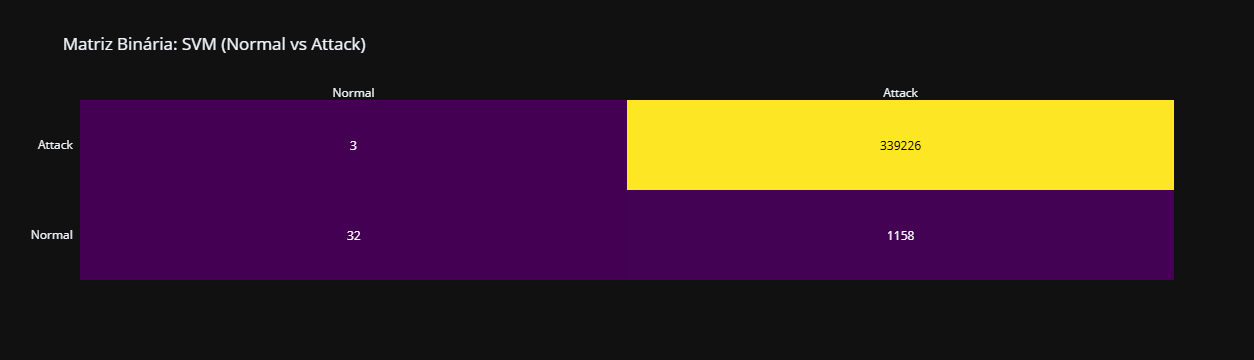

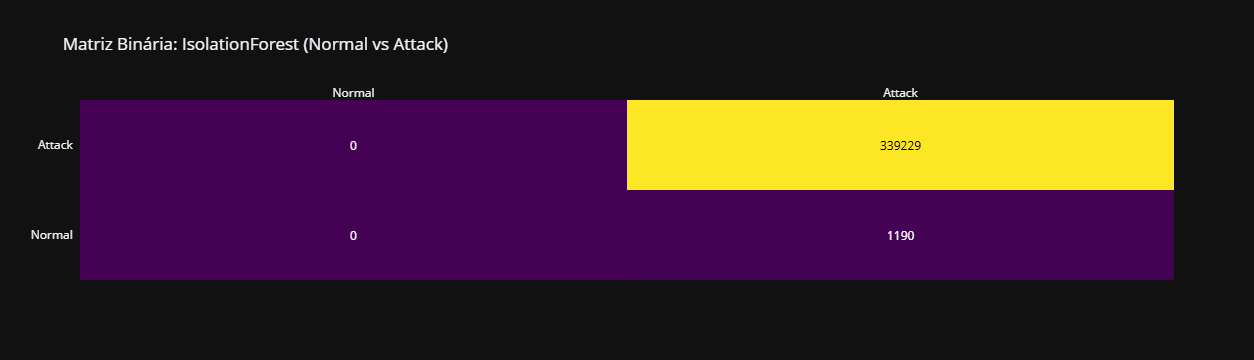

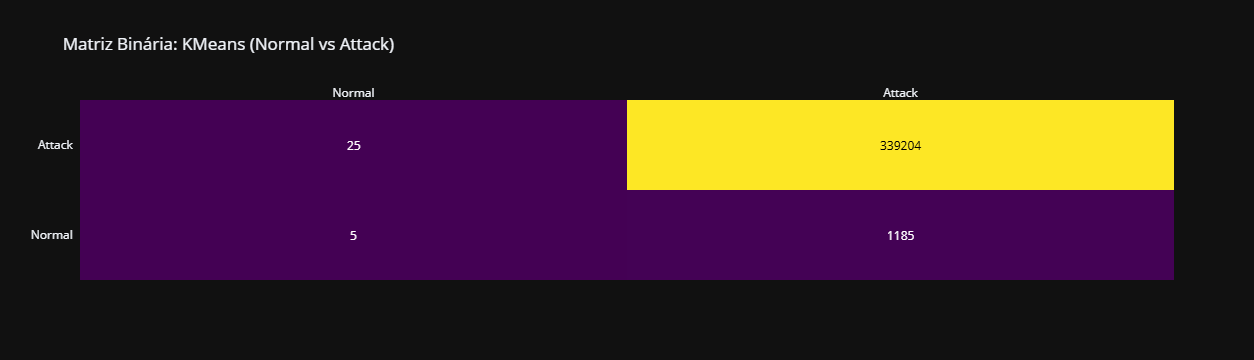


Matrizes Multiclasse (Detalhado):


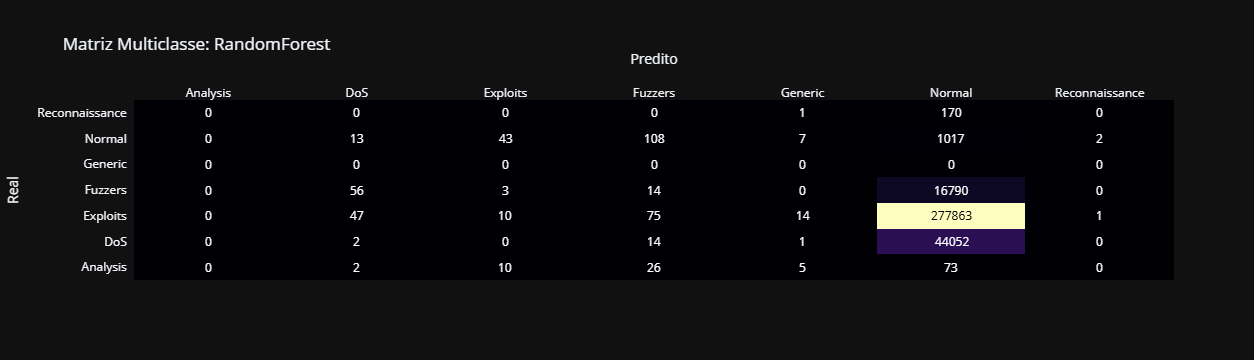

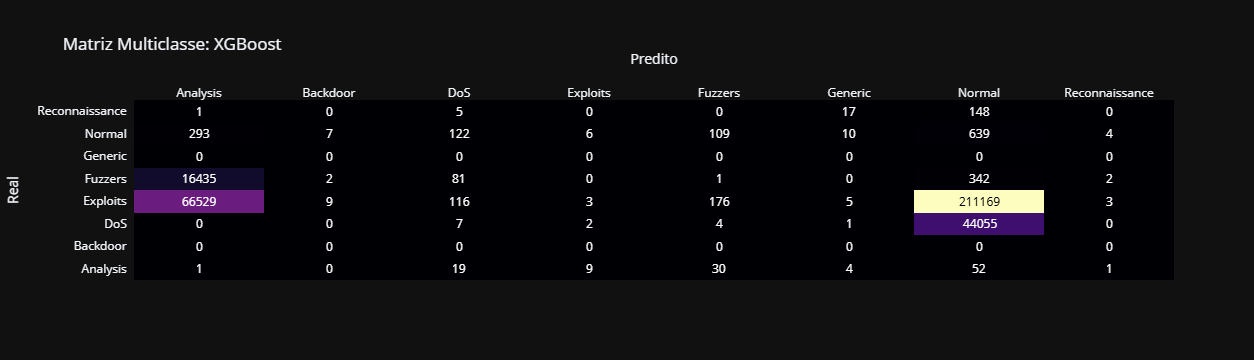

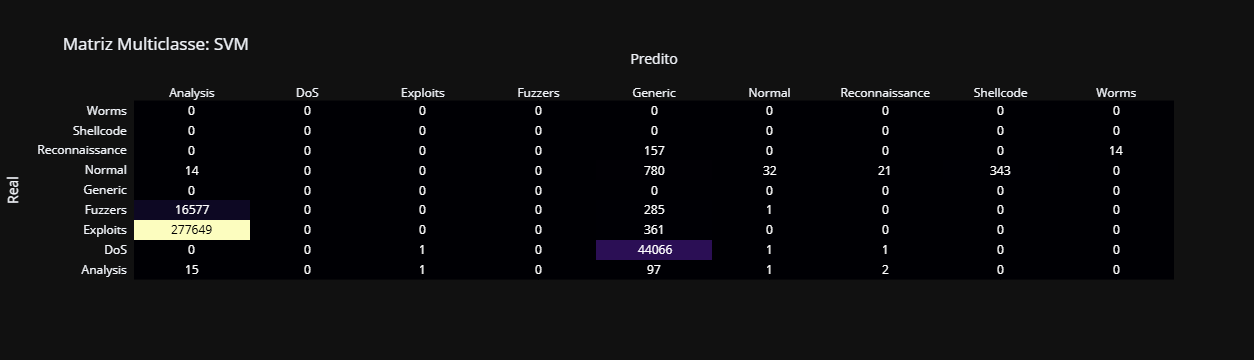

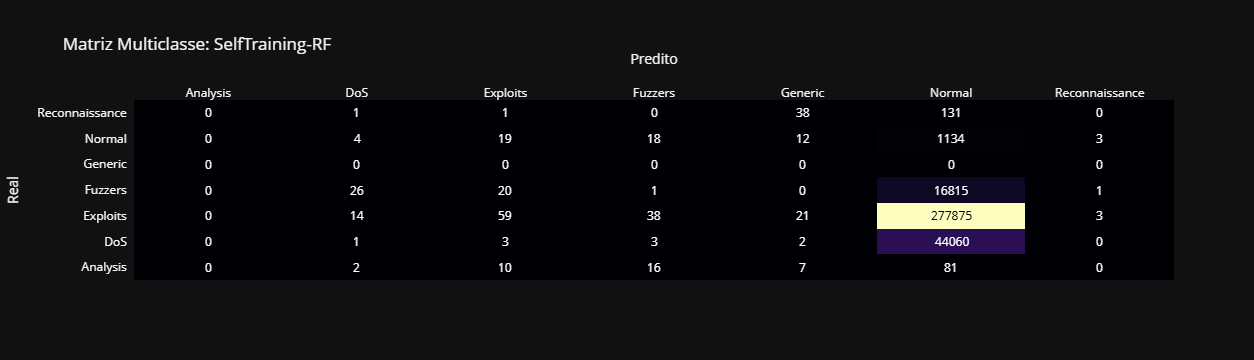

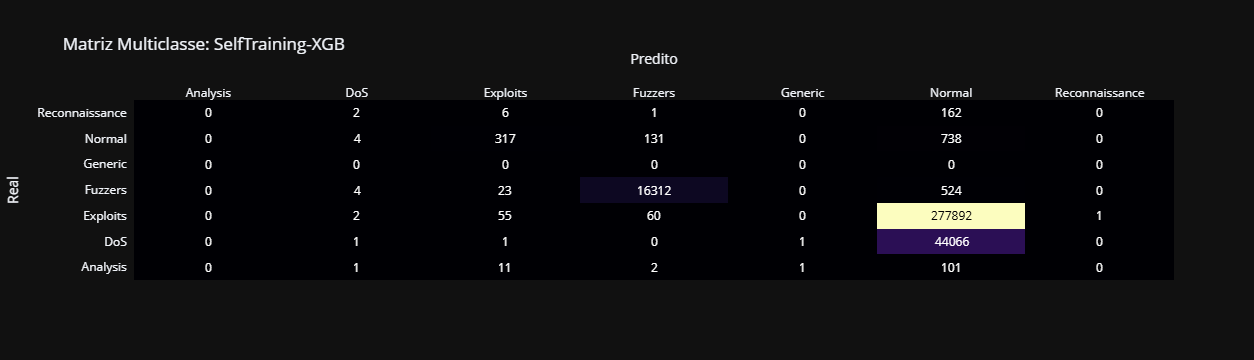

In [8]:
# --- 6. Visualização: Matrizes de Confusão ---

# Plotar Binárias (Top 3 Melhores)
if results_binary:
    top_bin = sorted(results_binary, key=lambda x: results_binary[x]['F1-Score'], reverse=True)[:3]
    print(f"\nTop 3 Modelos Binários (F1-Score): {top_bin}")
    
    for m in top_bin:
        cm = cm_binary[m]
        fig = ff.create_annotated_heatmap(
            z=cm, x=['Normal', 'Attack'], y=['Normal', 'Attack'], 
            colorscale='Viridis', annotation_text=[[str(y) for y in x] for x in cm]
        )
        fig.update_layout(title=f"Matriz Binária: {m} (Normal vs Attack)")
        fig.show()

# Plotar Multiclasse (Todos que rodaram)
if results_multi:
    print("\nMatrizes Multiclasse (Detalhado):")
    for m, (cm, labels) in cm_multi.items():
        fig = ff.create_annotated_heatmap(
            z=cm, x=list(labels), y=list(labels), 
            colorscale='Magma', annotation_text=[[str(y) for y in x] for x in cm]
        )
        fig.update_layout(title=f"Matriz Multiclasse: {m}", xaxis_title="Predito", yaxis_title="Real")
        fig.show()